# 01b · X-ray Density Viewer

Visualise a CCP4 / MTZ electron-density map alongside the CrossDocked pocket atoms: map statistics, value histogram, 2D slices, and an interactive 3D isosurface.

In [2]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import gemmi

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
ELEM_COLOR = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod",
              "F": "green", "Cl": "lime", "P": "orange"}


## 1. Config

Set the CCP4 map and the matching CrossDocked pocket PDB. For a different target, change `PDB_ID` and the script auto-locates the pocket PDB.

In [3]:
PDB_ID     = "14gs"
CCP4_FILE  = Path("14gs.ccp4")   # or DATA_DIR / "ccp4" / f"{PDB_ID}.map"
POCKET_DIR = Path("..") / "voxbind" / "dataset" / "data" / "crossdocked_pocket10"

candidates = sorted(POCKET_DIR.rglob(f"*{PDB_ID}*pocket10.pdb"))
if not candidates:
    raise FileNotFoundError(f"No pocket PDB found for {PDB_ID} under {POCKET_DIR}")
POCKET_PDB = candidates[0]

print(f"CCP4 map   : {CCP4_FILE}")
print(f"Pocket PDB : {POCKET_PDB.relative_to(POCKET_DIR.parent)}")


CCP4 map   : 14gs.ccp4
Pocket PDB : crossdocked_pocket10/GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb


## 2. Load map and metadata

In [4]:
m = gemmi.read_ccp4_map(str(CCP4_FILE))
m.setup(float('nan'))
grid = m.grid

arr  = np.array(grid, dtype=np.float32)   # (nu, nv, nw)
cell = grid.unit_cell
nu, nv, nw = arr.shape

mean  = float(np.nanmean(arr))
sigma = float(np.nanstd(arr))
pct_neg = 100.0 * np.sum(arr < 0) / arr.size

print(f"Grid shape  : {nu} x {nv} x {nw}")
print(f"Space group : {grid.spacegroup.hm}")
print(f"Unit cell   : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f} \u00c5")
print(f"              \u03b1={cell.alpha:.2f}  \u03b2={cell.beta:.2f}  \u03b3={cell.gamma:.2f}\u00b0")
print(f"Map mean    : {mean:.4f}")
print(f"Map sigma   : {sigma:.4f}")
print(f"% negative  : {pct_neg:.1f}%  (>50% \u2192 EDS/difference map)")

Grid shape  : 60 x 72 x 50
Space group : C 1 2 1
Unit cell   : a=78.651  b=91.826  c=69.143 Å
              α=90.00  β=98.25  γ=90.00°
Map mean    : 0.0000
Map sigma   : 0.1973
% negative  : 52.8%  (>50% → EDS/difference map)


## 3. Load pocket atoms

In [5]:
st = gemmi.read_structure(str(POCKET_PDB))

pocket_atoms = []  # list of (x, y, z, element)
for model in st:
    for chain in model:
        for res in chain:
            for atom in res:
                pos = atom.pos
                pocket_atoms.append((pos.x, pos.y, pos.z, atom.element.name))

pocket_xyz   = np.array([[a[0], a[1], a[2]] for a in pocket_atoms])  # (N, 3) Angstrom
pocket_elems = [a[3] for a in pocket_atoms]

# Cartesian \u2192 fractional \u2192 grid index
pocket_grid = np.zeros_like(pocket_xyz)
for i, (x, y, z) in enumerate(pocket_xyz):
    frac = cell.fractionalize(gemmi.Position(x, y, z))
    pocket_grid[i] = [frac.x * nu, frac.y * nv, frac.z * nw]

centroid = pocket_grid.mean(axis=0)

print(f"Pocket atoms    : {len(pocket_atoms)}")
print(f"Centroid (grid) : u={centroid[0]:.1f}  v={centroid[1]:.1f}  w={centroid[2]:.1f}")

Pocket atoms    : 255
Centroid (grid) : u=19.7  v=7.6  w=19.6


## 4. Density histogram (σ contour levels)

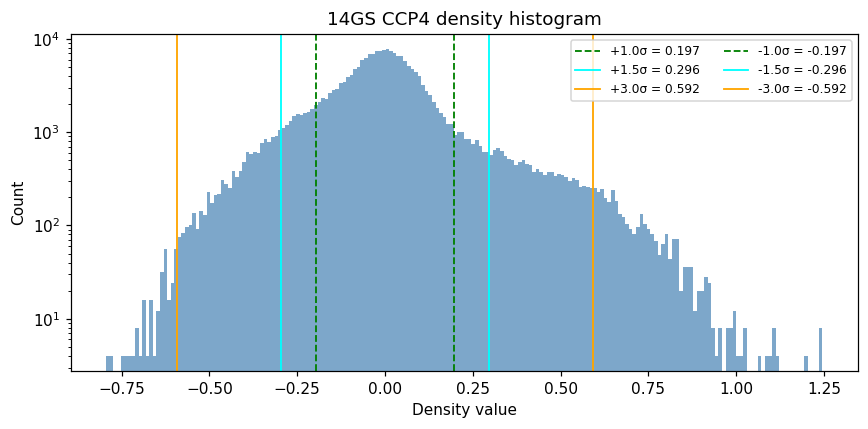

Contour levels:  +1.5σ = 0.2959   +3σ = 0.5919
               −1.5σ = -0.2959   −3σ = -0.5919


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
vals = arr.ravel()
ax.hist(vals, bins=200, color="steelblue", alpha=0.7, edgecolor="none")

for level, color, ls in [
    ( 1.0, "green",  "--"),
    ( 1.5, "cyan",   "-"),
    ( 3.0, "orange", "-"),
    (-1.0, "green",  "--"),
    (-1.5, "cyan",   "-"),
    (-3.0, "orange", "-"),
]:
    v = mean + level * sigma
    ax.axvline(v, color=color, ls=ls, lw=1.2, label=f"{level:+.1f}\u03c3 = {v:.3f}")

ax.set_xlabel("Density value")
ax.set_ylabel("Count")
ax.set_title(f"{PDB_ID.upper()} CCP4 density histogram")
ax.legend(fontsize=8, ncol=2)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"Contour levels:  +1.5\u03c3 = {mean + 1.5*sigma:.4f}   +3\u03c3 = {mean + 3*sigma:.4f}")
print(f"               \u22121.5\u03c3 = {mean - 1.5*sigma:.4f}   \u22123\u03c3 = {mean - 3*sigma:.4f}")

## 5. 2D orthogonal slices through pocket centroid

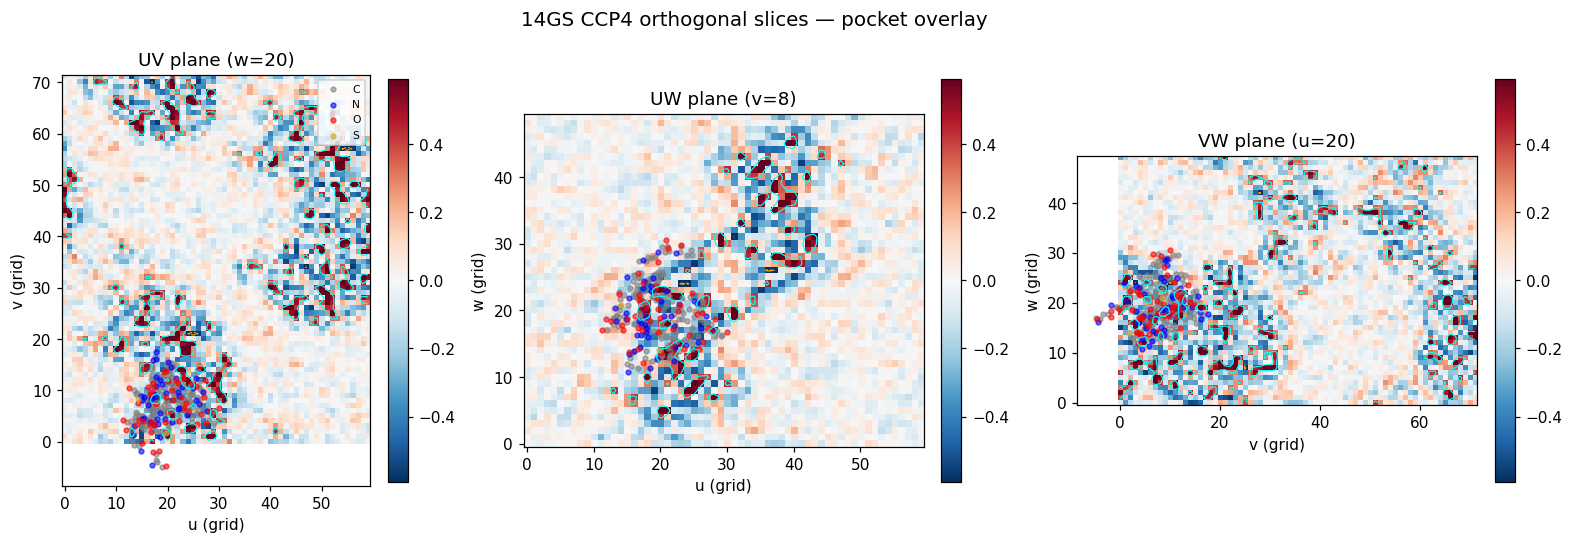

In [7]:
ci = int(np.clip(round(centroid[0]), 0, nu - 1))
cj = int(np.clip(round(centroid[1]), 0, nv - 1))
ck = int(np.clip(round(centroid[2]), 0, nw - 1))

vmin, vmax = mean - 3 * sigma, mean + 3 * sigma

slice_specs = [
    (f"UV plane (w={ck})", arr[:, :, ck], pocket_grid[:, 0], pocket_grid[:, 1], "u (grid)", "v (grid)"),
    (f"UW plane (v={cj})", arr[:, cj, :], pocket_grid[:, 0], pocket_grid[:, 2], "u (grid)", "w (grid)"),
    (f"VW plane (u={ci})", arr[ci, :, :], pocket_grid[:, 1], pocket_grid[:, 2], "v (grid)", "w (grid)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, slc, px, py, xl, yl) in zip(axes, slice_specs):
    im = ax.imshow(slc.T, origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.contour(slc.T, levels=[mean + 1.5 * sigma],
               colors=["cyan"],   linewidths=0.8)
    ax.contour(slc.T, levels=[mean - 3.0 * sigma],
               colors=["orange"], linewidths=0.8, linestyles="dashed")

    for elem in sorted(set(pocket_elems)):
        mask = np.array([e == elem for e in pocket_elems])
        ax.scatter(np.array(px)[mask], np.array(py)[mask],
                   c=ELEM_COLOR.get(elem, "purple"), s=10,
                   alpha=0.6, label=elem)

    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle(f"{PDB_ID.upper()} CCP4 orthogonal slices \u2014 pocket overlay", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 3D isosurface + pocket atoms

**Blue** = +1.5σ (positive density),  **red** = −3σ (negative / missing density).

In [8]:
# Sub-box around pocket centroid
R = 18
i0, i1 = max(0, ci - R), min(nu, ci + R)
j0, j1 = max(0, cj - R), min(nv, cj + R)
k0, k1 = max(0, ck - R), min(nw, ck + R)
sub = arr[i0:i1, j0:j1, k0:k1]

# Grid indices → Cartesian Å (monoclinic: x = a*fa + c*cos(β)*fc)
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

ii = np.arange(i0, i1, dtype=float) / nu
jj = np.arange(j0, j1, dtype=float) / nv
kk = np.arange(k0, k1, dtype=float) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc = a_len * Fi + c_len * math.cos(beta_rad) * Fk
Yc = b_len * Fj
Zc = c_len * math.sin(beta_rad) * Fk

pos_thresh = mean + 1.5 * sigma
neg_thresh = mean - 3.0 * sigma

traces = []

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=pos_thresh, isomax=pos_thresh,
    surface_count=1,
    colorscale=[[0, "blue"], [1, "blue"]],
    showscale=False, opacity=0.35,
    name="+1.5σ",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

traces.append(go.Isosurface(
    x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(),
    value=sub.ravel(),
    isomin=neg_thresh, isomax=neg_thresh,
    surface_count=1,
    colorscale=[[0, "red"], [1, "red"]],
    showscale=False, opacity=0.25,
    name="−3σ",
    caps=dict(x_show=False, y_show=False, z_show=False),
))

for elem in sorted(set(pocket_elems)):
    mask = np.array([e == elem for e in pocket_elems])
    xyz  = pocket_xyz[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=3, color=ELEM_COLOR.get(elem, "purple"), opacity=0.8),
        name=f"pocket {elem}",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{PDB_ID.upper()} CCP4 — 3D isosurface + pocket atoms",
    scene=dict(
        xaxis_title="X (Å)",
        yaxis_title="Y (Å)",
        zaxis_title="Z (Å)",
        aspectmode="data",
    ),
    width=800, height=650,
)
fig.show()

## 7. (Optional) Build CCP4 from MTZ

Convert a local `.mtz` file to a CCP4 map via `gemmi`. Adjust column labels (common: `FWT/PHWT`, `2FOFCWT/PH2FOFCWT`, `2mFo-DFc/P2mFo-DFc`).

In [9]:
MTZ_PATH = None   # set to Path("your.mtz") to convert

if MTZ_PATH is not None:
    mtz = gemmi.read_mtz_file(str(MTZ_PATH))
    print("MTZ columns:", [c.label for c in mtz.columns])

    f_col   = next((c.label for c in mtz.columns
                    if any(k in c.label for k in ("FWT", "2FOFCWT", "2mFo"))), None)
    phi_col = next((c.label for c in mtz.columns
                    if any(k in c.label for k in ("PHWT", "PH2FOFCWT", "P2mFo"))), None)
    print(f"Using F={f_col}  PHI={phi_col}")

    grid_mtz = mtz.transform_f_phi_to_map(f_col, phi_col, sample_rate=3.0)
    out = gemmi.Ccp4Map()
    out.grid = grid_mtz
    out.update_ccp4_header()
    out_path = MTZ_PATH.with_suffix(".ccp4")
    out.write_ccp4_map(str(out_path))
    print(f"Wrote {out_path}")
else:
    print("No MTZ — set MTZ_PATH above to use this section.")


No MTZ — set MTZ_PATH above to use this section.
